1. load the dataset

In [2]:
import pandas as pd

df=pd.read_csv("DS4_crossdomain_features_daily.csv")

print(df.head())
print(df.info())
print(df.describe())

         date  commodity    mqi  supply_disruption_prob  \
0  2014-01-02  Steel_HRC  78.30                  0.1809   
1  2014-01-03  Steel_HRC  77.77                  0.1727   
2  2014-01-06  Steel_HRC  77.41                  0.1729   
3  2014-01-07  Steel_HRC  77.09                  0.1754   
4  2014-01-08  Steel_HRC  76.97                  0.1793   

   substitution_elasticity  green_premium_per_kg  carbon_intensity_virgin  \
0                   0.4194                 0.149                     2.08   
1                   0.3940                 0.147                     2.11   
2                   0.3967                 0.152                     2.08   
3                   0.4721                 0.144                     2.16   
4                   0.4274                 0.149                     2.08   

   carbon_intensity_recycled  herfindahl_index  mqi_5d_trend  mqi_21d_trend  \
0                       0.42            0.0729           NaN            NaN   
1                       

2.Check Missing Values

In [3]:
print(df.isnull().sum())

date                           0
commodity                      0
mqi                            0
supply_disruption_prob         0
substitution_elasticity        0
green_premium_per_kg           0
carbon_intensity_virgin        0
carbon_intensity_recycled      0
herfindahl_index               0
mqi_5d_trend                  40
mqi_21d_trend                168
mqi_63d_trend                504
dtype: int64


In [4]:
import pandas as pd

df = pd.read_csv("DS4_crossdomain_features_daily.csv")

# Missing values per column
print(df.isnull().sum())

# Percentage of missing values
print((df.isnull().sum() / len(df)) * 100)

date                           0
commodity                      0
mqi                            0
supply_disruption_prob         0
substitution_elasticity        0
green_premium_per_kg           0
carbon_intensity_virgin        0
carbon_intensity_recycled      0
herfindahl_index               0
mqi_5d_trend                  40
mqi_21d_trend                168
mqi_63d_trend                504
dtype: int64
date                         0.000000
commodity                    0.000000
mqi                          0.000000
supply_disruption_prob       0.000000
substitution_elasticity      0.000000
green_premium_per_kg         0.000000
carbon_intensity_virgin      0.000000
carbon_intensity_recycled    0.000000
herfindahl_index             0.000000
mqi_5d_trend                 0.174277
mqi_21d_trend                0.731962
mqi_63d_trend                2.195887
dtype: float64


In [5]:
df_clean = df.dropna()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (22952, 12)
Cleaned Shape: (22448, 12)


In [7]:
print(df.isnull().sum())

date                         0
commodity                    0
mqi                          0
supply_disruption_prob       0
substitution_elasticity      0
green_premium_per_kg         0
carbon_intensity_virgin      0
carbon_intensity_recycled    0
herfindahl_index             0
mqi_5d_trend                 0
mqi_21d_trend                0
mqi_63d_trend                0
dtype: int64


Average MQI by commodity

In [8]:
df.groupby('commodity')['mqi'].mean()

commodity
Aluminium        82.063789
Cobalt_Index     74.147117
Copper           85.452935
Iron_Ore         79.810582
Lithium_ETF      68.893426
Nickel           71.811527
RareEarth_ETF    62.395078
Steel_HRC        78.445950
Name: mqi, dtype: float64

Highest supply disruption risk

In [10]:
df.groupby('commodity')[
'supply_disruption_prob'
].mean()

commodity
Aluminium        0.130160
Cobalt_Index     0.558118
Copper           0.138722
Iron_Ore         0.099194
Lithium_ETF      0.430417
Nickel           0.337256
RareEarth_ETF    0.870122
Steel_HRC        0.181488
Name: supply_disruption_prob, dtype: float64

Highest green premium

In [11]:
df.groupby('commodity')[
'green_premium_per_kg'
].mean()

commodity
Aluminium        0.849074
Cobalt_Index     4.098633
Copper           0.220001
Iron_Ore         0.080016
Lithium_ETF      2.502179
Nickel           1.199413
RareEarth_ETF    0.000000
Steel_HRC        0.149776
Name: green_premium_per_kg, dtype: float64

Highest carbon intensity

In [12]:
df.groupby('commodity')[
'carbon_intensity_virgin'
].mean()

commodity
Aluminium        12.001684
Cobalt_Index     22.004339
Copper            3.499240
Iron_Ore          1.800014
Lithium_ETF      15.001318
Nickel            8.002715
RareEarth_ETF    25.009348
Steel_HRC         2.098397
Name: carbon_intensity_virgin, dtype: float64

Average Herfindahl Index

In [13]:
df.groupby('commodity')[
'herfindahl_index'
].mean()

commodity
Aluminium        0.120034
Cobalt_Index     0.449864
Copper           0.150115
Iron_Ore         0.180002
Lithium_ETF      0.350104
Nickel           0.219930
RareEarth_ETF    0.719933
Steel_HRC        0.079963
Name: herfindahl_index, dtype: float64

MQI trend analysis


In [14]:
df[['mqi_5d_trend',
'mqi_21d_trend',
'mqi_63d_trend']].describe()

,mqi_5d_trend,mqi_21d_trend,mqi_63d_trend
count,22952.000000,22952.000000,22952.000000
mean,0.000829,0.006653,0.010550
std,1.091147,2.115451,3.279368
min,-3.850000,-9.060000,-13.460000
25%,-0.730000,-1.370000,-2.210000
50%,0.000000,0.030000,0.020000
75%,0.740000,1.410000,2.120000
max,4.320000,8.130000,13.640000


MQI volatility


In [15]:
df.groupby('commodity')['mqi'].std()

commodity
Aluminium        3.370290
Cobalt_Index     3.478861
Copper           3.389297
Iron_Ore         2.978807
Lithium_ETF      3.011607
Nickel           2.958958
RareEarth_ETF    3.791336
Steel_HRC        3.868871
Name: mqi, dtype: float64

Supply risk vs MQI


In [16]:
df[['mqi','supply_disruption_prob']].corr()


,mqi,supply_disruption_prob
mqi,1.000000,-0.798608
supply_disruption_prob,-0.798608,1.000000


Carbon vs Green Premium

In [17]:
df[['green_premium_per_kg',
'carbon_intensity_virgin']].corr()

,green_premium_per_kg,carbon_intensity_virgin
green_premium_per_kg,1.000000,0.511974
carbon_intensity_virgin,0.511974,1.000000


 Highest MQI commodity


In [19]:
df.groupby('commodity')['mqi'].mean()

commodity
Aluminium        82.063789
Cobalt_Index     74.147117
Copper           85.452935
Iron_Ore         79.810582
Lithium_ETF      68.893426
Nickel           71.811527
RareEarth_ETF    62.395078
Steel_HRC        78.445950
Name: mqi, dtype: float64

Sustainable commodities


In [21]:
df[df['carbon_intensity_virgin']<df['carbon_intensity_virgin'].median()]


,date,commodity,mqi,supply_disruption_prob,substitution_elasticity,green_premium_per_kg,carbon_intensity_virgin,carbon_intensity_recycled,herfindahl_index,mqi_5d_trend,mqi_21d_trend,mqi_63d_trend
0,2014-01-02,Steel_HRC,78.30,0.1809,0.4194,0.149,2.08,0.42,0.0729,0.00,0.03,0.02
1,2014-01-03,Steel_HRC,77.77,0.1727,0.3940,0.147,2.11,0.40,0.0767,0.00,0.03,0.02
2,2014-01-06,Steel_HRC,77.41,0.1729,0.3967,0.152,2.08,0.39,0.0881,0.00,0.03,0.02
3,2014-01-07,Steel_HRC,77.09,0.1754,0.4721,0.144,2.16,0.41,0.0758,0.00,0.03,0.02
4,2014-01-08,Steel_HRC,76.97,0.1793,0.4274,0.149,2.08,0.39,0.0794,0.00,0.03,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...
22947,2024-12-25,Iron_Ore,81.67,0.0989,0.1596,0.079,1.83,0.29,0.1827,-0.89,0.02,0.37
22948,2024-12-26,Iron_Ore,82.08,0.1111,0.1501,0.080,1.86,0.29,0.1787,-1.04,0.91,0.95
22949,2024-12-27,Iron_Ore,81.54,0.1037,0.1439,0.080,1.80,0.30,0.1838,-0.71,-0.16,0.87
22950,2024-12-30,Iron_Ore,81.16,0.1028,0.1624,0.081,1.80,0.31,0.1788,-1.16,0.12,0.22


 High-risk commodities


In [22]:

df[
df['supply_disruption_prob']>0.5
]


,date,commodity,mqi,supply_disruption_prob,substitution_elasticity,green_premium_per_kg,carbon_intensity_virgin,carbon_intensity_recycled,herfindahl_index,mqi_5d_trend,mqi_21d_trend,mqi_63d_trend
12301,2017-03-02,Lithium_ETF,70.74,0.5036,0.2190,2.513,14.95,7.52,0.3538,-0.48,0.99,0.46
12884,2019-05-28,Lithium_ETF,63.55,0.5011,0.2315,2.555,14.56,8.30,0.3542,0.07,-0.96,-2.74
12898,2019-06-17,Lithium_ETF,63.74,0.5124,0.2134,2.501,14.87,7.84,0.3552,0.26,0.77,-2.71
12899,2019-06-18,Lithium_ETF,63.40,0.5088,0.1720,2.549,15.28,7.73,0.3426,0.00,0.06,-2.30
12900,2019-06-19,Lithium_ETF,63.81,0.5071,0.2045,2.358,15.46,7.78,0.3492,1.09,0.33,-2.04
...,...,...,...,...,...,...,...,...,...,...,...,...
20078,2024-12-25,RareEarth_ETF,56.84,0.8983,0.1004,0.000,25.12,0.00,0.7264,-0.17,0.65,1.79
20079,2024-12-26,RareEarth_ETF,56.97,0.9029,0.1037,0.000,25.05,0.00,0.7172,-0.68,0.83,2.24
20080,2024-12-27,RareEarth_ETF,56.94,0.8951,0.1584,0.000,25.68,0.00,0.7130,-0.31,0.22,2.62
20081,2024-12-30,RareEarth_ETF,56.21,0.8852,0.1545,0.000,24.72,0.00,0.7161,-0.82,-0.31,1.50


ESG Ranking

In [24]:
df.groupby('commodity')[
['mqi',
'green_premium_per_kg']
].mean()

,mqi,green_premium_per_kg
commodity,,
Aluminium,82.063789,0.849074
Cobalt_Index,74.147117,4.098633
Copper,85.452935,0.220001
Iron_Ore,79.810582,0.080016
Lithium_ETF,68.893426,2.502179
Nickel,71.811527,1.199413
RareEarth_ETF,62.395078,0.000000
Steel_HRC,78.445950,0.149776


Average MQI by Commodity

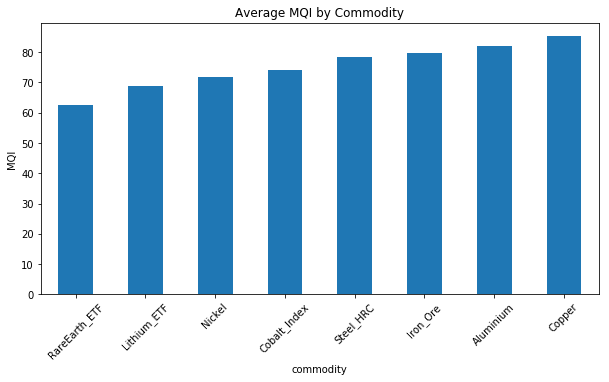

In [26]:
import matplotlib.pyplot as plt

avg_mqi = df.groupby('commodity')['mqi'].mean().sort_values()

plt.figure(figsize=(10,5))
avg_mqi.plot(kind='bar')
plt.title("Average MQI by Commodity")
plt.ylabel("MQI")
plt.xticks(rotation=45)
plt.show()

supply Disruption Risk by Commodity

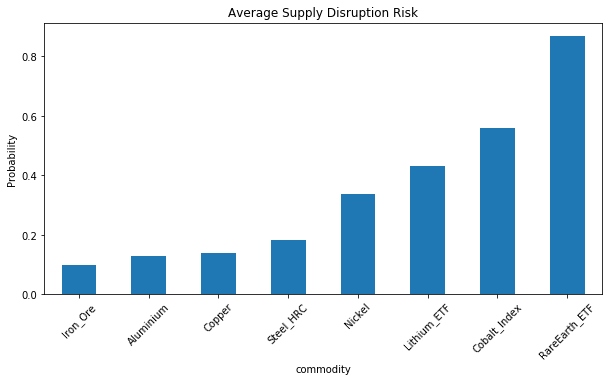

In [27]:
risk = df.groupby('commodity')['supply_disruption_prob'].mean().sort_values()

plt.figure(figsize=(10,5))
risk.plot(kind='bar')
plt.title("Average Supply Disruption Risk")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.show()

ESG Analysis

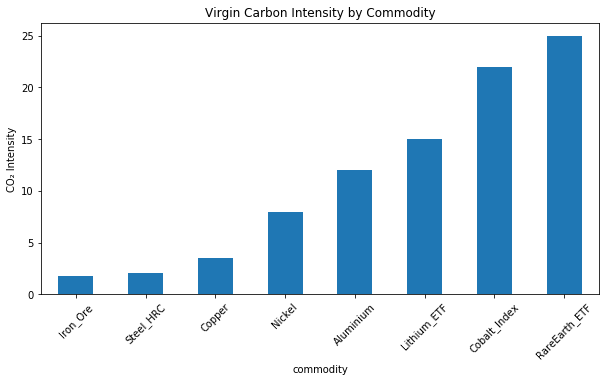

In [28]:
carbon = df.groupby('commodity')['carbon_intensity_virgin'].mean().sort_values()

plt.figure(figsize=(10,5))
carbon.plot(kind='bar')
plt.title("Virgin Carbon Intensity by Commodity")
plt.ylabel("CO₂ Intensity")
plt.xticks(rotation=45)
plt.show()

Green Premium Analysis

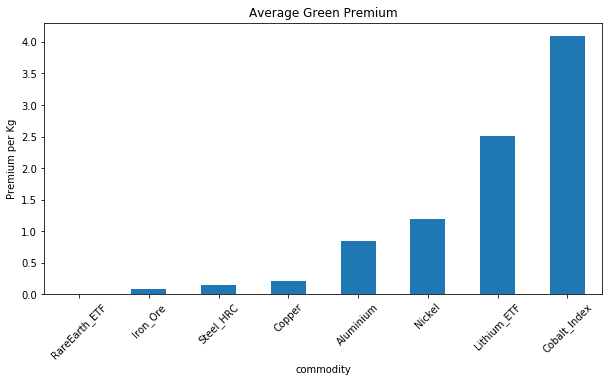

In [29]:
premium = df.groupby('commodity')['green_premium_per_kg'].mean().sort_values()

plt.figure(figsize=(10,5))
premium.plot(kind='bar')
plt.title("Average Green Premium")
plt.ylabel("Premium per Kg")
plt.xticks(rotation=45)
plt.show()

MQI Distribution

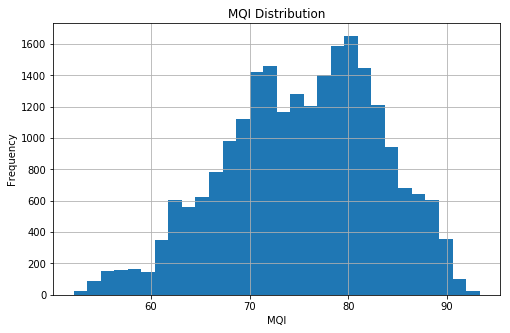

In [30]:
plt.figure(figsize=(8,5))
df['mqi'].hist(bins=30)

plt.title("MQI Distribution")
plt.xlabel("MQI")
plt.ylabel("Frequency")
plt.show()

Correlation Heatmap

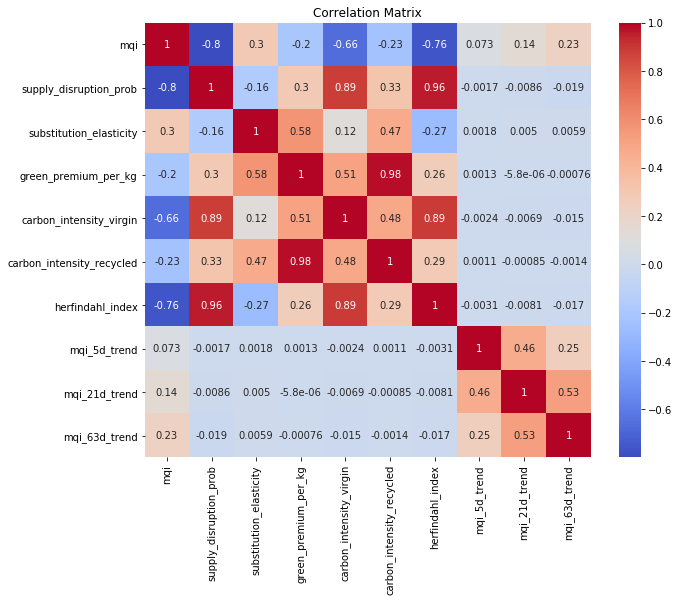

In [31]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Supply Risk vs MQI

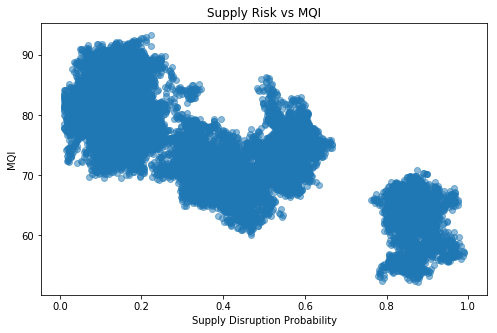

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['supply_disruption_prob'],
    df['mqi'],
    alpha=0.5
)

plt.xlabel("Supply Disruption Probability")
plt.ylabel("MQI")
plt.title("Supply Risk vs MQI")

plt.show()

Carbon Intensity vs Green Premium

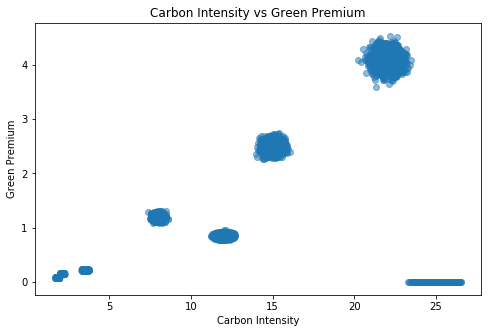

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['carbon_intensity_virgin'],
    df['green_premium_per_kg'],
    alpha=0.5
)

plt.xlabel("Carbon Intensity")
plt.ylabel("Green Premium")
plt.title("Carbon Intensity vs Green Premium")

plt.show()

Herfindahl Index by Commodity

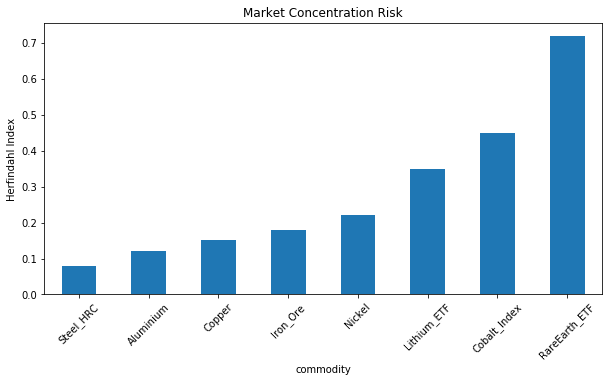

In [37]:
hhi = df.groupby('commodity')['herfindahl_index'].mean().sort_values()

plt.figure(figsize=(10,5))
hhi.plot(kind='bar')

plt.title("Market Concentration Risk")
plt.ylabel("Herfindahl Index")
plt.xticks(rotation=45)

plt.show()

Commodity Risk Dashboard

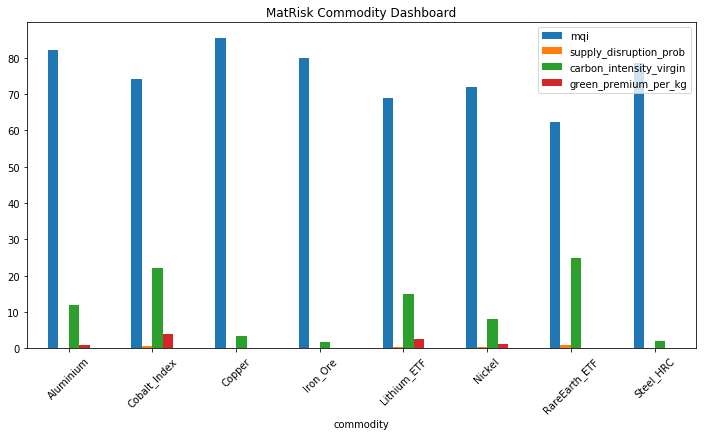

In [35]:
dashboard = df.groupby('commodity').agg({
    'mqi':'mean',
    'supply_disruption_prob':'mean',
    'carbon_intensity_virgin':'mean',
    'green_premium_per_kg':'mean'
})

dashboard.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("MatRisk Commodity Dashboard")
plt.xticks(rotation=45)
plt.show()